# Naming colors

If you are shown random colors evenly spaced across the color spectrum, what percentage of those colors would the average person name red? What about green? 

English speakers in the United States were shown 80 color chips in random order in controlled lighting condtions. These 80 colors are evenly spaced across the standard Munsell array of colors. The participants were told: "There are 11 choices: black, white, red, green, blue, purple, brown, yellow, orange, pink, gray. Choose the closest color word".

This study was then repeated with Bolivian-Spanish speakers in Bolivia and Tsimane' speakers from the Amazon.

The dataset `munsell-array-fixed-choice.csv` shows the most common name in each language for each color chip.

In [ ]:
# FOR GOOGLE COLAB ONLY.
# Uncomment and run the code below. A dialog will appear to upload files.
# Upload 'munsell-array-fixed-choice.csv'.

# from google.colab import files
# uploaded = files.upload()

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("munsell-array-fixed-choice.csv")
df.head()

,grid,x,y,munsell_code,tile_hex,english_color,spanish_color,tsimane_color,spanish,tsimane
0,B1,1,7,5R8/6,#fbb6b0,pink,pink,yellow,rosada (pink),chamus (yellow)
1,D1,1,5,5R6/12,#eb6a68,pink,pink,red,rosada (pink),jainas (red)
2,F1,1,3,5R4/14,#bb1933,red,red,red,rojo (red),jainas (red)
3,H1,1,1,5R2/8,#610d25,red,red,brown,rojo (red),cafedyeisi (brown)
4,A2,2,8,10R9/2,#f2ded8,pink,white,white,blanco (white),jaibas (white)


The function below plots the 80 evenly spaced colors that each study participant was shown in random order.

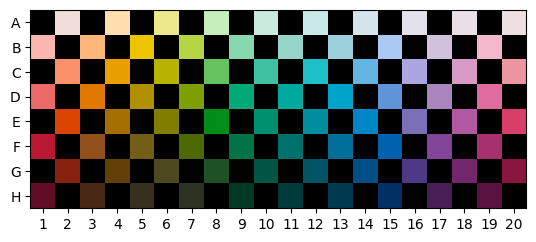

In [2]:
def plot_colors(color_column):
    fig, ax = plt.subplots()
    for idx, row in df.iterrows():
        ax.add_patch(plt.Rectangle((row['x'] - 0.5, row['y'] - 0.5), 1, 1, color=row[color_column], linewidth=0))

    ax.set_xlim(0.5, 20.5)
    ax.set_ylim(0.5, 8.5)
    ax.set_aspect('equal')
    ax.set_facecolor('black')
    ax.set_xticks(range(1, 21))
    ax.set_yticks(range(1, 9), ['H', 'G', 'F', 'E', 'D', 'C', 'B', 'A'])

plot_colors('tile_hex')

We can also use this function to plot the most common name in each language for each color chip.

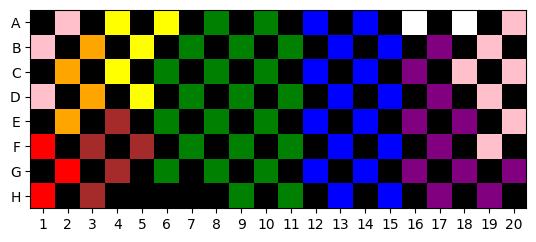

In [3]:
# Also try 'spanish_color' and 'tsimane_color'
plot_colors('english_color')

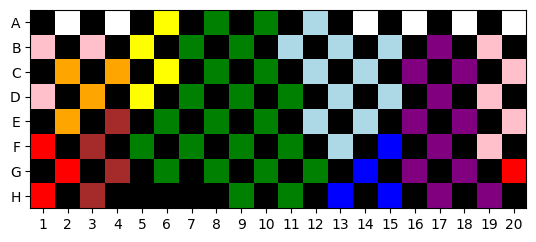

In [4]:
plot_colors('spanish_color')

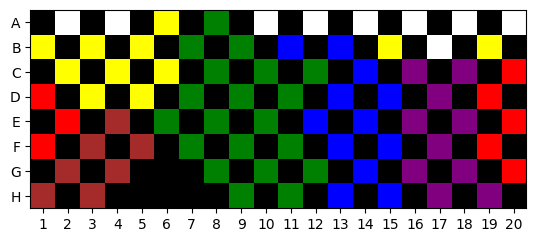

In [5]:
plot_colors('tsimane_color')

### Project Ideas:

- For each language, calculate what percentage of chips are named each color. Return dataframes for each language.

- Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

- Is there a correlation between languages? Create scatter plots. 
	- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.
	
	- You might need to `merge` dataframes.


In [ ]:
# YOUR CODE HERE (add more cells as needed)

- Since there are 80 color chips in total, the percentage of chips for a given color name is:

$$\text{Percentage} = \left( \frac{\text{Count of chips named X}}{\text{Total chips (80)}} \right) \times 100$$

In [21]:
# We calculate this for english_color, spanish_color, and tsimane_color

total_chips = len(df)

# for english color
english_counts = df['english_color'].value_counts()
eng_df = ((english_counts/total_chips)*100).reset_index()
eng_df.columns = ['color', "english_percent"]

# spanish
spanish_counts = df['spanish_color'].value_counts()
spanish_df = ((spanish_counts/total_chips)*100).reset_index()
spanish_df.columns = ['color', 'spanish_percent']

# tsimane_color
tsimane_count = df['tsimane_color'].value_counts()
tsimane_df = ((tsimane_count/total_chips)*100).reset_index()
tsimane_df.columns = ['color', 'tsimane_percent']

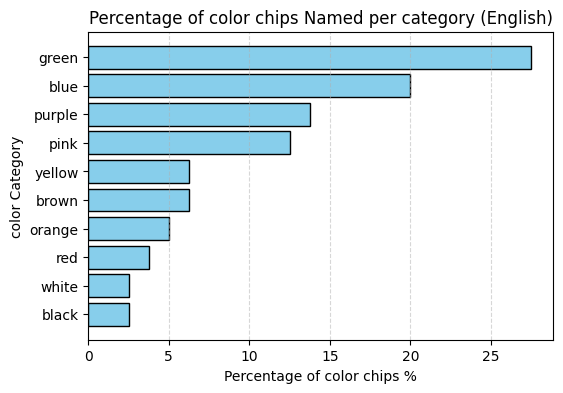

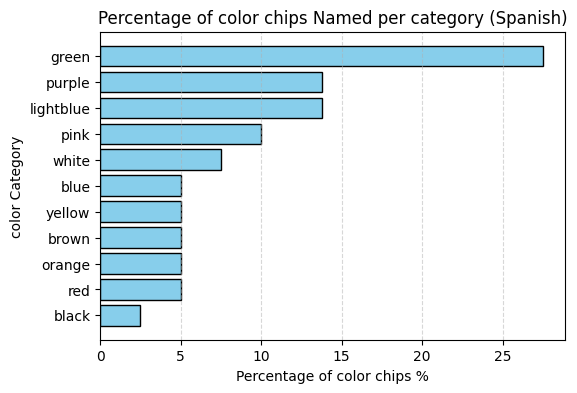

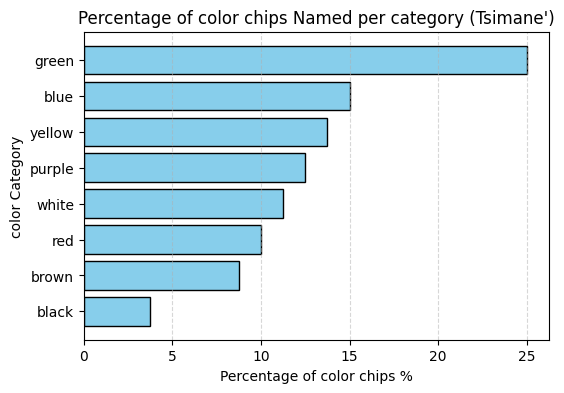

In [25]:
# Create a horizontal bar plot for each language. Each bar represents a color name and the length encodes the percentage of chips that are named that color.

def plot_color_bar(lang_df, color_col, lang_name):
    df_sorted = lang_df.sort_values(by=color_col, ascending=True)
    
    plt.figure(figsize=(6,4))
    plt.barh(df_sorted['color'], df_sorted[color_col], color='skyblue', edgecolor='black')
    plt.xlabel("Percentage of color chips %")
    plt.ylabel("color Category")
    plt.title(f"Percentage of color chips Named per category ({lang_name})")
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    plt.show()
    
plot_color_bar(eng_df, 'english_percent', 'English')
plot_color_bar(spanish_df, 'spanish_percent', 'Spanish')
plot_color_bar(tsimane_df, 'tsimane_percent', "Tsimane'")

- Is there a correlation between languages? Create scatter plots.

- Hint: the x-axis could be the percentage of chips for English speakers and the y-axis could be the percentage of chips for Tsimane speakers and each data point represents a color name.

- You might need to merge dataframes.

In [27]:
df1 = pd.merge(eng_df, spanish_df, on='color', how='outer')

In [28]:
df1 = pd.merge(df1, tsimane_df, on='color', how='outer')
df1.head()

,color,english_percent,spanish_percent,tsimane_percent
0,green,27.50,27.50,25.00
1,blue,20.00,5.00,15.00
2,purple,13.75,13.75,12.50
3,pink,12.50,10.00,NaN
4,brown,6.25,5.00,8.75


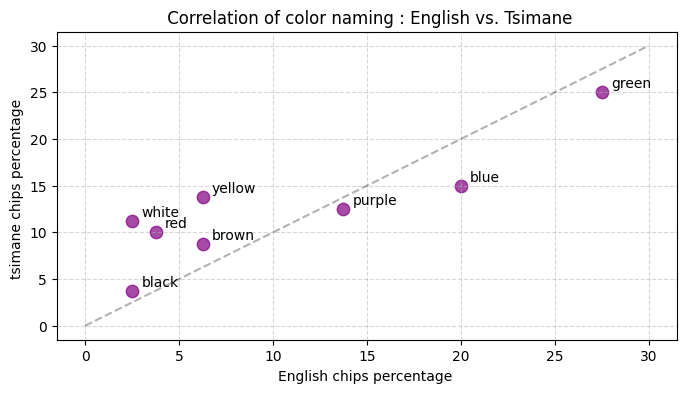

In [32]:
# English vs. Tsimane

plt.figure(figsize=(8,4))
plt.scatter(df1['english_percent'], df1['tsimane_percent'], color='purple',s=80, alpha=0.7)

# label data point with its color name
for idx , row in df1.iterrows():
    plt.annotate(row['color'], (row['english_percent']+0.5, row['tsimane_percent']+0.5))

# add line of equality (y=x) for visual comparison
plt.plot([0,30],[0,30], 'k--', alpha=0.3, label='1:1 Agreement')

plt.xlabel("English chips percentage ")
plt.ylabel("tsimane chips percentage ")
plt.title(" Correlation of color naming : English vs. Tsimane")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

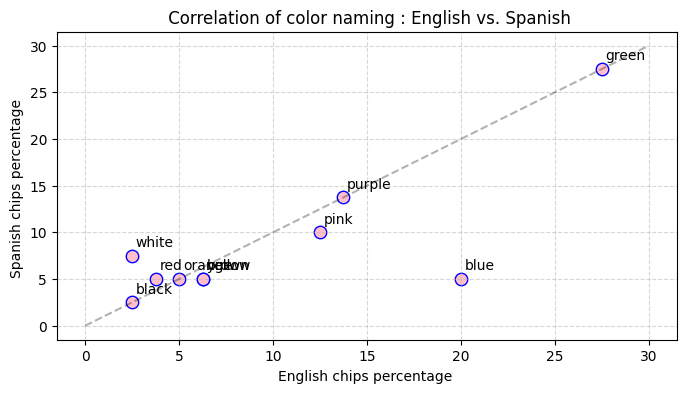

In [48]:
# English vs. spanish

plt.figure(figsize=(8,4))
plt.scatter(df1['english_percent'], df1['spanish_percent'], color='pink', edgecolor='blue',s=80, alpha=1)

# label data point with its color name
for idx , row in df1.iterrows():
    plt.annotate(row['color'], (row['english_percent']+0.2, row['spanish_percent']+1))

# add line of equality (y=x) for visual comparison
plt.plot([0,30],[0,30], 'k--', alpha=0.3, label='1:1 Agreement')

plt.xlabel("English chips percentage ")
plt.ylabel("Spanish chips percentage ")
plt.title(" Correlation of color naming : English vs. Spanish")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

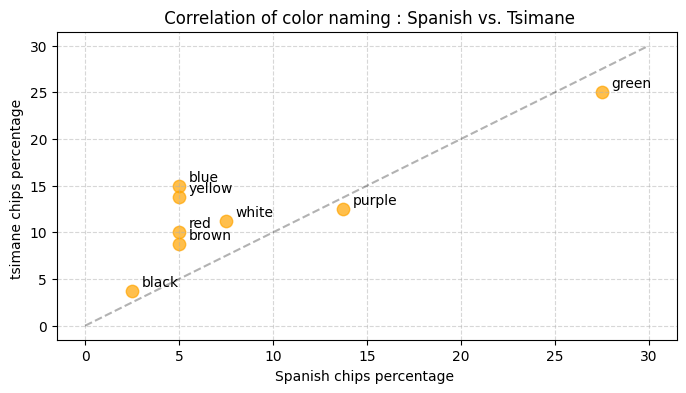

In [40]:
# Spanish vs. Tsimane

plt.figure(figsize=(8,4))
plt.scatter(df1['spanish_percent'], df1['tsimane_percent'], color='orange',s=80, alpha=0.7)

# label data point with its color name
for idx , row in df1.iterrows():
    plt.annotate(row['color'], (row['spanish_percent']+0.5, row['tsimane_percent']+0.5))

# add line of equality (y=x) for visual comparison
plt.plot([0,30],[0,30], 'k--', alpha=0.3, label='1:1 Agreement')

plt.xlabel("Spanish chips percentage ")
plt.ylabel("tsimane chips percentage ")
plt.title(" Correlation of color naming : Spanish vs. Tsimane")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

- Across all three languages, basic terms like green occupy the largest percentage of the color space (around 25–27.5%), placing it almost directly on the $y = x$ line of equality in every scatter plot.

- English and Spanish speakers distinguish fine-grained categories like pink or blue at higher rates, whereas Tsimane' speakers group a broader set of light or warm shades into terms like yellow (chamus) or white (jaibas).